<a href="https://colab.research.google.com/github/ardiwaaaa/Processing_Data/blob/main/Progress_uas_3_14970.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 1. MEMUAT DATASET ===

> 5 Baris Pertama Dataset:
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_reque

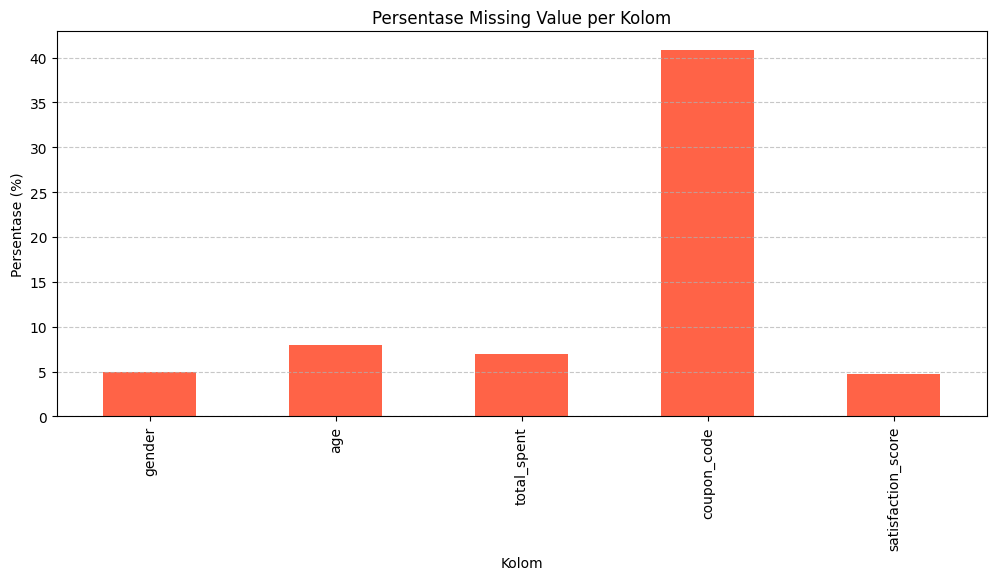


=== 3. DISTRIBUSI VARIABEL TARGET (CHURN) ===


/tmp/ipykernel_4266/3662587470.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='Set2')


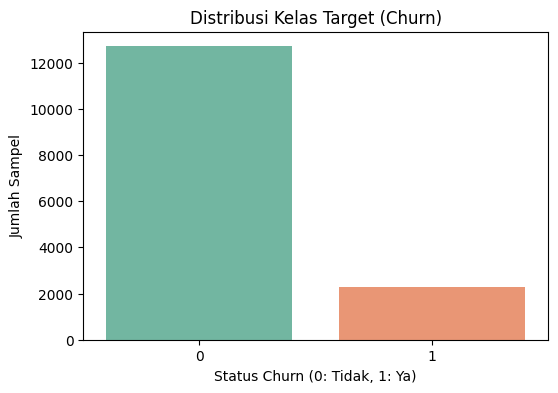


=== 4. HEATMAP KORELASI (FITUR NUMERIK) ===


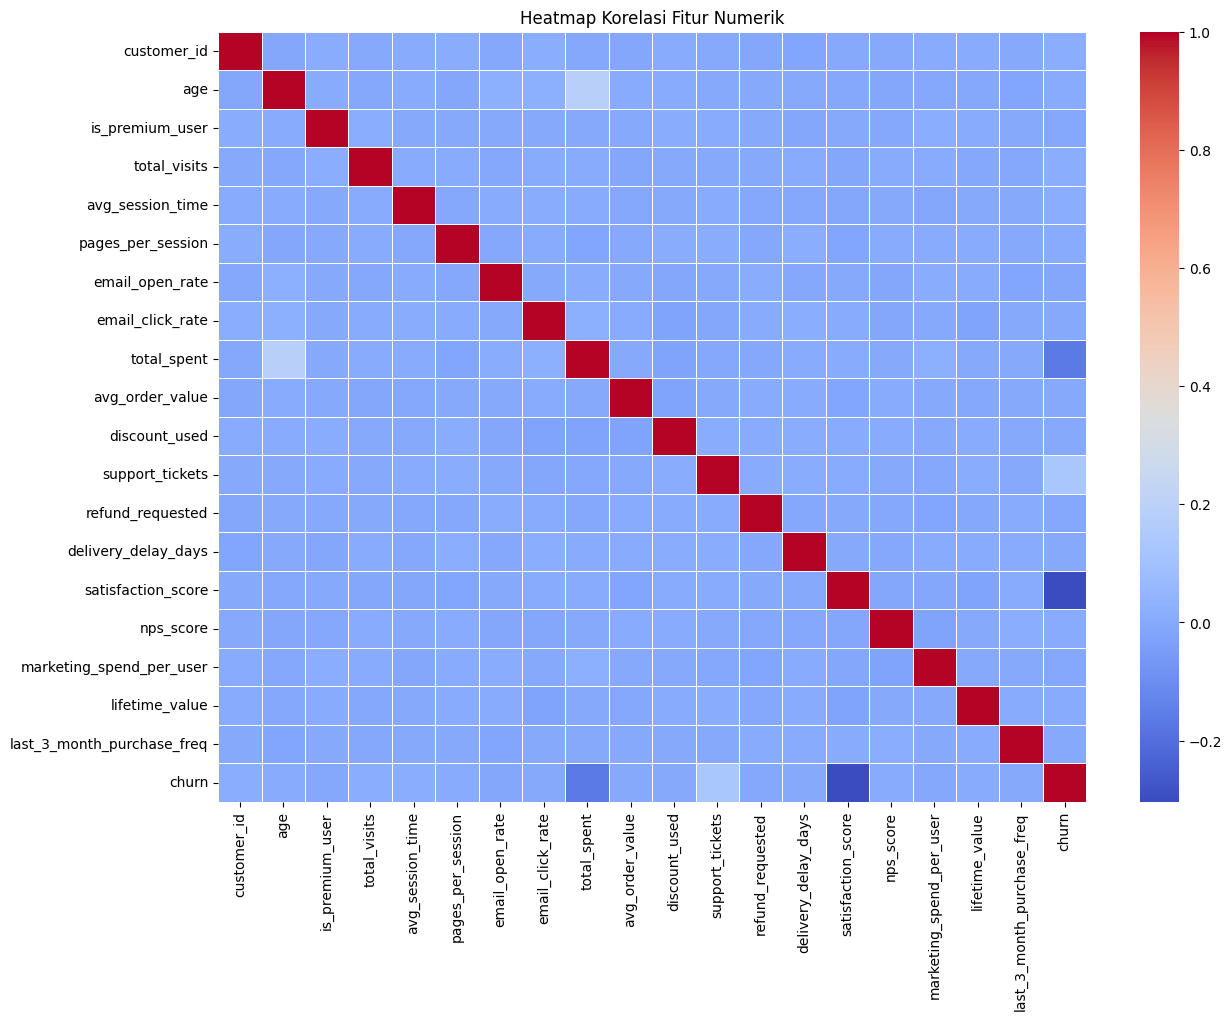


=== 5. DIRECT MODELING ===

--- Performa Model: K-Nearest Neighbors (Konvensional) ---
Accuracy : 0.8376
Precision: 0.4681
Recall   : 0.1697
F1-Score : 0.2491

Confusion Matrix:
[[1986   75]
 [ 323   66]]

--- Performa Model: Random Forest (Ensemble Bagging) ---
Accuracy : 0.8420
Precision: 0.5034
Recall   : 0.3753
F1-Score : 0.4300

Confusion Matrix:
[[1917  144]
 [ 243  146]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Performa Model: Voting Classifier (Ensemble Voting) ---
Accuracy : 0.8449
Precision: 0.5652
Recall   : 0.1003
F1-Score : 0.1703

Confusion Matrix:
[[2031   30]
 [ 350   39]]


In [8]:
# ==============================================================================
# MINGGU 1: EDA & DIRECT MODELING
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------------------------------------
# 1. Exploratory Data Analysis (EDA)
# ------------------------------------------------------------------------------
print("=== 1. MEMUAT DATASET ===")
# Load dataset (Sesuaikan path file jika menggunakan Google Colab)
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')

# Menampilkan 5 baris pertama
print("\n> 5 Baris Pertama Dataset:")
print(df.head())

# Menampilkan informasi dataset (tipe data & non-null counts)
print("\n> Informasi Dataset:")
print(df.info())

# Menampilkan statistik deskriptif
print("\n> Statistik Deskriptif:")
print(df.describe(include='all'))

print("\n=== 2. ANALISIS MISSING VALUE ===")
# Menghitung persentase missing value
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

# Visualisasi Missing Value dengan Diagram Batang
plt.figure(figsize=(12, 5))
missing_percentage[missing_percentage > 0].plot(kind='bar', color='tomato')
plt.title('Persentase Missing Value per Kolom')
plt.ylabel('Persentase (%)')
plt.xlabel('Kolom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n=== 3. DISTRIBUSI VARIABEL TARGET (CHURN) ===")
# Visualisasi keseimbangan kelas target 'churn'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Distribusi Kelas Target (Churn)')
plt.xlabel('Status Churn (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Sampel')
plt.show()

print("\n=== 4. HEATMAP KORELASI (FITUR NUMERIK) ===")
# Filter hanya kolom numerik saja untuk heatmap korelasi
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()


# ------------------------------------------------------------------------------
# 2. Direct Modeling (Baseline)
# ------------------------------------------------------------------------------
print("\n=== 5. DIRECT MODELING ===")

# Untuk direct modeling, kita drop kolom objek/datetime agar model tidak error saat training awal
# Kolom yang bertipe string/text tidak bisa langsung diproses oleh KNN/Random Forest tanpa encoding
df_direct = df.select_dtypes(include=[np.number]).dropna()

# Menetapkan X dan y
X_direct = df_direct.drop(columns=['churn'])
y_direct = df_direct['churn']

# Train-Test Split (80:20)
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

# Inisialisasi 3 Kategori Model
clf_knn_dir = KNeighborsClassifier(n_neighbors=5)
clf_rf_dir = RandomForestClassifier(random_state=42)

# Ensemble Voting (Kombinasi Logistic Regression & KNN)
clf_log_dir = LogisticRegression(max_iter=1000, random_state=42)
clf_voting_dir = VotingClassifier(
    estimators=[('lr', clf_log_dir), ('knn', clf_knn_dir)],
    voting='soft'
)

# Kamus model untuk mempermudah perulangan evaluasi
models_direct = {
    "K-Nearest Neighbors (Konvensional)": clf_knn_dir,
    "Random Forest (Ensemble Bagging)": clf_rf_dir,
    "Voting Classifier (Ensemble Voting)": clf_voting_dir
}

# Training dan Evaluasi Direct Model
for name, model in models_direct.items():
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)

    print(f"\n--- Performa Model: {name} ---")
    print(f"Accuracy : {accuracy_score(y_test_dir, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_dir, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test_dir, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test_dir, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_dir, y_pred))

In [9]:
# ==============================================================================
# MINGGU 2: PREPROCESSING & MODELING
# ==============================================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("\n=== 6. DATA PREPROCESSING ===")

# Copy dataframe asli untuk dibersihkan
df_clean = df.copy()

# 1. Menghapus fitur yang tidak relevan (seperti ID unik atau tanggal pendaftaran mentah)
columns_to_drop = ['customer_id', 'signup_date', 'last_purchase_date']
# Cek apakah kolom ada sebelum melakukan drop demi menghindari error
columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=columns_to_drop)

# 2. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

# 3. Mendefinisikan kolom numerik dan kategorikal
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Fitur Numerik   : {numerical_features}")
print(f"Fitur Kategorikal: {categorical_features}")

# 4. Train-Test Split (Proporsi SAMA dengan Minggu 1 agar adil)
X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Membuat Pipeline Preprocessing menggunakan ColumnTransformer
# Pipeline untuk data numerik: Imputasi dengan Median + Scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline untuk data kategorikal: Imputasi dengan Modus + One Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Gabungkan transformer numerik dan kategorikal
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# 6. Terapkan Preprocessing pada data train dan data test
X_train_ready = preprocessor.fit_transform(X_train_prep)
X_test_ready = preprocessor.transform(X_test_prep)

print(f"\nBentuk data setelah preprocessing: {X_train_ready.shape}")

print("\n=== 7. MODELING DENGAN DATA PREPROCESSED ===")

# Inisialisasi Ulang Model (Menggunakan data yang sudah bersih)
clf_knn_prep = KNeighborsClassifier(n_neighbors=5)
clf_rf_prep = RandomForestClassifier(random_state=42)

clf_log_prep = LogisticRegression(max_iter=1000, random_state=42)
clf_voting_prep = VotingClassifier(
    estimators=[('lr', clf_log_prep), ('knn', clf_knn_prep)],
    voting='soft'
)

models_prep = {
    "K-Nearest Neighbors (Preprocessed)": clf_knn_prep,
    "Random Forest (Preprocessed)": clf_rf_prep,
    "Voting Classifier (Preprocessed)": clf_voting_prep
}

# Training dan Evaluasi Model Ter-preprocessing
for name, model in models_prep.items():
    model.fit(X_train_ready, y_train_prep)
    y_pred = model.predict(X_test_ready)

    print(f"\n--- Performa Model: {name} ---")
    print(f"Accuracy : {accuracy_score(y_test_prep, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_prep, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test_prep, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test_prep, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_prep, y_pred))


=== 6. DATA PREPROCESSING ===
Fitur Numerik   : ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']
Fitur Kategorikal: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']

Bentuk data setelah preprocessing: (12000, 51)

=== 7. MODELING DENGAN DATA PREPROCESSED ===

--- Performa Model: K-Nearest Neighbors (Preprocessed) ---
Accuracy : 0.8447
Precision: 0.4717
Recall   : 0.1087
F1-Score : 0.1767

Confusion Matrix:
[[2484   56]
 [ 410   50]]

--- Performa Model: Random Forest (Preprocessed) ---
Accuracy : 0.8463
Precision: 0.4972
Recall   : 0.1935
F1-Score : 0.2786

Confusion Matrix:
[[2450   90]
 [ 371   89]]

--- Performa Model


=== 8. FEATURE IMPORTANCE ANALYSIS ===
> Top 10 Fitur Paling Berpengaruh terhadap Churn:
1. Fitur 'total_spent' (0.1867)
2. Fitur 'satisfaction_score' (0.1680)
3. Fitur 'support_tickets' (0.0670)
4. Fitur 'avg_session_time' (0.0418)
5. Fitur 'pages_per_session' (0.0415)
6. Fitur 'marketing_spend_per_user' (0.0412)
7. Fitur 'lifetime_value' (0.0400)
8. Fitur 'avg_order_value' (0.0392)
9. Fitur 'email_open_rate' (0.0355)
10. Fitur 'age' (0.0335)


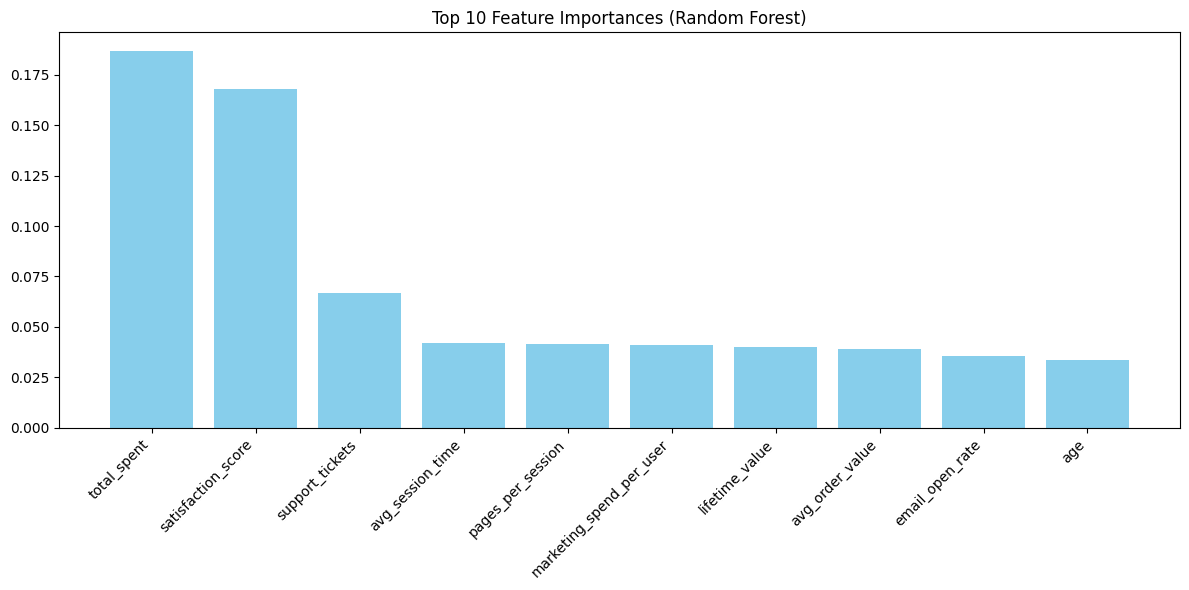


=== 9. HYPERPARAMETER TUNING ===
> Best Parameters KNN: {'n_neighbors': 3, 'weights': 'uniform'}
> Best Parameters Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

=== 10. EVALUASI DAN PERBANDINGAN PERFORMA AKHIR ===

> Tabel Perbandingan Performa Model (Tuned):
             Model Name  Accuracy  Precision   Recall  F1-Score
              KNN Tuned  0.837000   0.418079 0.160870  0.232339
    Random Forest Tuned  0.840333   0.447514 0.176087  0.252730
Voting Classifier Tuned  0.849667   0.545455 0.117391  0.193202

[INFO] Model terbaik berhasil diekspor menjadi 'best_churn_model.pkl' dan siap di-deploy!


In [10]:
# ==============================================================================
# MINGGU 3: HYPERPARAMETER TUNING & FEATURE SELECTION
# ==============================================================================

from sklearn.model_selection import GridSearchCV

print("\n=== 8. FEATURE IMPORTANCE ANALYSIS ===")

# Mengambil nama kolom baru hasil OneHotEncoder untuk visualisasi
encoded_cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
all_features_names = numerical_features + encoded_cat_features

# Mengambil tingkat kepentingan fitur dari model Random Forest Minggu ke-2
importances = clf_rf_prep.feature_importances_
indices = np.argsort(importances)[::-1]

# Ambil 10 Fitur paling berpengaruh
top_n = 10
print(f"> Top {top_n} Fitur Paling Berpengaruh terhadap Churn:")
for f in range(top_n):
    print(f"{f + 1}. Fitur '{all_features_names[indices[f]]}' ({importances[indices[f]]:.4f})")

# Visualisasi Feature Importance
plt.figure(figsize=(12, 6))
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.bar(range(top_n), importances[indices[:top_n]], color="skyblue", align="center")
plt.xticks(range(top_n), [all_features_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("\n=== 9. HYPERPARAMETER TUNING ===")

# Skenario pencarian hyperparameter terbaik menggunakan GridSearchCV
# 1. Tuning K-Nearest Neighbors
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train_ready, y_train_prep)
print(f"> Best Parameters KNN: {grid_knn.best_params_}")

# 2. Tuning Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_ready, y_train_prep)
print(f"> Best Parameters Random Forest: {grid_rf.best_params_}")

# 3. Tuning Voting Classifier menggunakan best estimator dari model individu
best_log_reg = LogisticRegression(max_iter=1000, random_state=42)
clf_voting_tuned = VotingClassifier(
    estimators=[('lr', best_log_reg), ('knn', grid_knn.best_estimator_)],
    voting='soft'
)
clf_voting_tuned.fit(X_train_ready, y_train_prep)


print("\n=== 10. EVALUASI DAN PERBANDINGAN PERFORMA AKHIR ===")

final_models = {
    "KNN Tuned": grid_knn.best_estimator_,
    "Random Forest Tuned": grid_rf.best_estimator_,
    "Voting Classifier Tuned": clf_voting_tuned
}

# Membuat list tampungan data untuk tabel komparasi akhir
summary_results = []

for name, model in final_models.items():
    y_pred = model.predict(X_test_ready)

    summary_results.append({
        "Model Name": name,
        "Accuracy": accuracy_score(y_test_prep, y_pred),
        "Precision": precision_score(y_test_prep, y_pred),
        "Recall": recall_score(y_test_prep, y_pred),
        "F1-Score": f1_score(y_test_prep, y_pred)
    })

# Mengubah hasil komparasi menjadi Dataframe agar rapi dibaca
df_summary = pd.DataFrame(summary_results)
print("\n> Tabel Perbandingan Performa Model (Tuned):")
print(df_summary.to_string(index=False))

# Menyimpan Model Terbaik (Misal Random Forest dipilih jadi model terbaik)
import joblib
best_model_file = 'best_churn_model.pkl'
joblib.dump(grid_rf.best_estimator_, best_model_file)
# Simpan juga objek preprocessor untuk dipakai di Streamlit nanti
joblib.dump(preprocessor, 'preprocessor.pkl')
print(f"\n[INFO] Model terbaik berhasil diekspor menjadi '{best_model_file}' dan siap di-deploy!")